In [209]:
#impoting necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.dates as mdates
import os
import urllib.request
import random
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
from numpy import trapezoid
from scipy.signal import argrelmin

# where you want the data to be taken from and where you want to plots to go
InputPath = 'DataFolder'
OutputPath = 'PlotsFolder/'



def Power_And_Irradiance_MeanMinMax(year, day):
    '''
    This function takes in the year and the day, then it returns a dictionary with mean min max values for
    the powers and the irradiances for those days
    '''
    #Take input for year(YY) and day of year(DDD)
    
    # year = 2025
    # day = 345
    
    input_1  = year
    input_2  = day
    
    baseurl = 'https://gml.noaa.gov/aftp/data/radiation/baseline/spo'
    year = input_1 # last two digits of the year (from input_1)
    
    Area = 2.0 #m**2
    
    try:
        # -----------------NOAA-----------------------------------
        NOAA = [] #list to hold dataframes
        for i in [ int(input_2) - 1, int(input_2)]: #previous day and current day to match the NZDT time and GMT time
            iid = '{0:03d}'.format(i) #format day of year to 3 digits (if Jan 1st, it should be 001, and so on)
            filename = f'{baseurl}/20{int(year)}/spo{int(year)}{iid}.dat' #construct the full filename
            print(filename) #print the filename being accessed
        
            try:
                file = urllib.request.urlopen(filename)
                data = file.read().decode('utf-8').split('\n') #read the file and split into lines
                #convert data to dataframe
                df = pd.DataFrame([row.split() for row in data[2:]])
                # print(dt)
                NOAA.append(df) #append dataframe to list
            except urllib.error.HTTPError:
                print(f"{filename} file not found") #print error if file not found
        
        # print('dir Irradiance data time correction')
        '''Direct Irradiance'''
        #define the direct irradiance and diffuse irradiance data with time correction for NZDT
        NOAAdir_ir_1 = NOAA[0][12]
        NOAAdir_ir_2 = NOAA[1][12]
        NOAAtemp = NOAA[0][38]
        # NOAAtemp = np.where(NOAAtemp == -9999.9, 0, 1)
        # print(f'NOAAtemp: {NOAAtemp}')
        # print(f'NOAAtemp sum: {np.sum(NOAAtemp)}')
        # concatenate the two days data with time correction
        NZDTdir_ir= pd.concat([NOAAdir_ir_1.iloc[660:1440], NOAAdir_ir_2.iloc[0:660]], axis = 0)
        #convert this to float
        NZDTdir_ir = NZDTdir_ir.astype(float)
        #remove nan values from NZDTdir_ir 
        NZDTdir_ir[NZDTdir_ir == -9999.9] = np.nan
        # NZDTdir_ir = np.array([random.randint(950, 1000) for _ in range(1440)]) # Generate a random integer between 950 and 1050
        # NZDTdir_ir = NZDTdir_ir.astype(float)
        # print(len(NZDTdir_ir))
        
        # print(NZDTdir_ir)
        
        # print('diff Irradiance data time correction')
        ''' Diffuse irradiance'''
        #diffuse irradiance
        NOAAdiff_ir_1 = NOAA[0][14]
        NOAAdiff_ir_2 = NOAA[1][14]
        
        # concatenate the two days data with time correction
        NZDTdiff_ir= pd.concat([NOAAdiff_ir_1.iloc[660:1440], NOAAdiff_ir_2.iloc[0:660]], axis = 0)
        NZDTdiff_ir = NZDTdiff_ir.astype(float) #convert this to float
        
        #remove nan values from NZDTdiff_ir 
        NZDTdiff_ir[NZDTdiff_ir == -9999.9] = np.nan #remove nan values
        # NZDTdiff_ir = np.array([random.randint(250, 350) for _ in range(1440)]) # Generate a random integer between 250 and 400
        # NZDTdiff_ir = NZDTdiff_ir.astype(float) #convert this to float
        
        ''' Upwelling irradiance'''
        #upwelling irradiance
        NOAAup_ir_1 = NOAA[0][10] 
        NOAAup_ir_2 = NOAA[1][10]
        NZDTup_ir= pd.concat([NOAAup_ir_1.iloc[660:1440], NOAAup_ir_2.iloc[0:660]], axis = 0) # concatenate the two days data with time correction
        NZDTup_ir = NZDTup_ir.astype(float)
        #remove nan values from NZDTup_ir 
        NZDTup_ir[NZDTup_ir == -9999.9] = np.nan
        # NZDTup_ir = np.array([random.randint(500, 600) for _ in range(1440)]) # Generate a random integer between 50 and 150
        # NZDTup_ir = NZDTup_ir.astype(float)

        '''Solar Zenith Angle'''
        NOAA_Zenith_1 = NOAA[0][7] 
        NOAA_Zenith_2 = NOAA[1][7]
        NZDT_Zenith= pd.concat([NOAA_Zenith_1.iloc[660:1440], NOAA_Zenith_2.iloc[0:660]], axis = 0) # concatenate the two days data with time correction
        NZDT_Zenith = NZDT_Zenith.astype(float)
        #remove nan values from NZDTup_ir 
        NZDT_Zenith[NZDT_Zenith == -9999.9] = np.nan
        
        
        '''Time List'''
        # print(NZDTdiff_ir)
        # Create a range of timestamps with a frequency of 1 minute ('min')
        times_list = pd.date_range("00:00:00", periods=1440, freq="min")
        
        # Format as HH:MM:SS strings
        NOAA_time = times_list.strftime("%H:%M:%S").tolist()    
        NOAA_time = pd.to_timedelta(pd.Series(NOAA_time))
        NOAA_time = NOAA_time.astype(str).str.split().str[-1]
        
        #time list for the device data
        times_list_device = pd.date_range("00:00:00", periods=2880, freq="min")
        
        # Format as HH:MM:SS strings
        device_time = times_list_device.strftime("%H:%M:%S").tolist()    
        device_time = pd.to_timedelta(pd.Series(device_time))
        device_time = device_time.astype(str).str.split().str[-1]
        IrrMeanMinMax = [[np.mean(NZDTdir_ir), np.min(NZDTdir_ir), np.max(NZDTdir_ir)], [np.mean(NZDTdiff_ir), np.min(NZDTdiff_ir), np.max(NZDTdiff_ir)], [np.mean(NZDTup_ir), np.min(NZDTup_ir), np.max(NZDTup_ir)]]
        
        Irradiance_Direct_mean = np.nanmean(NZDTdir_ir)
        Irradiance_Direct_min = np.min(NZDTdir_ir)
        Irradiance_Direct_max = np.max(NZDTdir_ir)

        Irradiance_Diffuse_mean = np.nanmean(NZDTdiff_ir)
        Irradiance_Diffuse_min = np.min(NZDTdiff_ir)
        Irradiance_Diffuse_max = np.max(NZDTdiff_ir)

        Irradiance_Upwelling_mean = np.nanmean(NZDTup_ir)
        Irradiance_Upwelling_min = np.min(NZDTup_ir)
        Irradiance_Upwelling_max = np.max(NZDTup_ir)

        Zenith_Angle_mean = np.nanmean(NZDT_Zenith)
        Zenith_Angle_min = np.min(NZDT_Zenith)
        Zenith_Angle_max = np.max(NZDT_Zenith)
        
    except FileNotFoundError:
        IrrMeanMinMax = [[np.nan,np.nan,np.nan], [np.nan,np.nan,np.nan], [np.nan,np.nan,np.nan]]

        Irradiance_Direct_mean = np.nan
        Irradiance_Direct_min = np.nan
        Irradiance_Direct_max = np.nan

        Irradiance_Diffuse_mean = np.nan
        Irradiance_Diffuse_min = np.nan
        Irradiance_Diffuse_max = np.nan

        Irradiance_Upwelling_mean = np.nan
        Irradiance_Upwelling_min = np.nan
        Irradiance_Upwelling_max = np.nan

        Zenith_Angle_mean = np.nan
        Zenith_Angle_min = np.nan
        Zenith_Angle_max = np.nan
        
    except IndexError:
        IrrMeanMinMax = [[np.nan,np.nan,np.nan], [np.nan,np.nan,np.nan], [np.nan,np.nan,np.nan]]

        Irradiance_Direct_mean = np.nan
        Irradiance_Direct_min = np.nan
        Irradiance_Direct_max = np.nan

        Irradiance_Diffuse_mean = np.nan
        Irradiance_Diffuse_min = np.nan
        Irradiance_Diffuse_max = np.nan

        Irradiance_Upwelling_mean = np.nan
        Irradiance_Upwelling_min = np.nan
        Irradiance_Upwelling_max = np.nan

        Zenith_Angle_mean = np.nan
        Zenith_Angle_min = np.nan
        Zenith_Angle_max = np.nan
        
    try:
        # --------REAL PANEL DATA-------------
        #Read the CSV files based on user input
        
        file_101 = pd.read_csv(f"{InputPath}/spo_dev101_{input_1}_{'{0:03d}'.format(input_2)}.csv",delimiter=',')
        file_103 = pd.read_csv(f"{InputPath}/spo_dev103_{input_1}_{'{0:03d}'.format(input_2)}.csv",delimiter=',')
        

        # Rename the Device ID column to voltage and Voltage to Current
        file_101.rename(columns = {'Device ID': 'V', 'Voltage': 'A'}, inplace=True)
        file_103.rename(columns = {'Device ID': 'V', 'Voltage': 'A'}, inplace=True) # There is a mismatch in the file so voltage column contains current and Device ID contains voltage
        
        # Each file has the data for more than just the day it is. We want to remove this extra dataS
        
        def date2num(date_str): # Renamed 'date' to 'date_str' to avoid confusion with the datetime.date object
            # 26 # first conver the xxxx-xx-xx format to date(xxxx, xx, xx)
        
            # You can skip splitting the string and go directly to parsing:
            date_object = datetime.strptime(date_str, '%Y-%m-%d').date()
            
            # 29 # return the day of the year (%j) as an integer
            # The strftime method returns a string, so we convert it to an integer.
            return int(date_object.strftime('%j'))
        # print(f'DEBUG: {input_2}')
        date = file_101['Date']
        NumberDate = date.apply(date2num)
        mask_to_keep =  NumberDate <= int(input_2)
        file_101 = file_101[mask_to_keep]
        # print(f'DEBUG: {mask_to_keep}')
        # print(f'DEBUG: {NumberDate}')
        
        date = file_103['Date']
        NumberDate = date.apply(date2num)
        mask_to_keep = NumberDate <= int(input_2)
        file_103 = file_103[mask_to_keep]
        
        #Extract time, voltage and current data
        
        time_101 = file_101['Time']
        voltage_101 = file_101['V'] 
        current_101 = file_101['A'] 
        
        time_103 = file_103['Time']
        voltage_103 = file_103['V'] 
        current_103 = file_103['A'] 
        
        power_101 = voltage_101 * current_101
        power_103 = voltage_103 * current_103
        # -----------------------------
        print(f'File Loaded {day}')
        PowerMeanMinMax = [[np.nanmean(power_101), np.min(power_101), np.max(power_101)],[np.nanmean(power_103), np.min(power_103), np.max(power_103)]]

        Power_101_mean = np.nanmean(power_101)
        Power_101_min = np.min(power_101)
        Power_101_max = np.max(power_101)
        Power_101_sd = np.std(power_101)

        Power_103_mean = np.nanmean(power_103)
        Power_103_min = np.min(power_101)
        Power_103_max = np.max(power_101)
        
    except FileNotFoundError:
        print('File Not Loaded')
        PowerMeanMinMax = [[np.nan, np.nan, np.nan], [np.nan, np.nan, np.nan]]

        Power_101_mean = np.nan
        Power_101_min = np.nan
        Power_101_max = np.nan
        Power_101_sd = np.nan
        

        Power_103_mean = np.nan
        Power_103_min = np.nan
        Power_103_max = np.nan
        
    except KeyError:
        print('File Not Loaded')
        PowerMeanMinMax = [[np.nan, np.nan, np.nan], [np.nan, np.nan, np.nan]]

        Power_101_mean = np.nan
        Power_101_min = np.nan
        Power_101_max = np.nan
        Power_101_sd = np.nan
        

        Power_103_mean = np.nan
        Power_103_min = np.nan
        Power_103_max = np.nan
        
    # except 
    ValuesToReturn = {'Irradiance_Direct_mean':Irradiance_Direct_mean,
                     'Irradiance_Direct_min':Irradiance_Direct_min,
                     'Irradiance_Direct_max':Irradiance_Direct_max,
                     'Irradiance_Diffuse_mean':Irradiance_Diffuse_mean,
                     'Irradiance_Diffuse_min':Irradiance_Diffuse_min,
                     'Irradiance_Diffuse_max':Irradiance_Diffuse_max,
                     'Irradiance_Upwelling_mean':Irradiance_Upwelling_mean,
                     'Irradaince_Upwelling_min':Irradiance_Upwelling_min,
                     'Irradaince_Upwelling_max':Irradiance_Upwelling_max,
                     'Power_101_mean':Power_101_mean,
                     'Power_101_min':Power_101_min,
                     'Power_101_max':Power_101_max,
                      'Power_101_sd':Power_101_sd,
                     'Power_103_mean':Power_103_mean,
                     'Power_103_min':Power_103_min,
                     'Power_103_max':Power_103_max,
                     'Zenith_Angle_mean':Zenith_Angle_mean,
                     'Zenith_Angle_min':Zenith_Angle_min,
                     'Zenith_Angle_max':Zenith_Angle_max}
    return ValuesToReturn



In [210]:
Day_Range2025 = np.arange(334, 366, 1)
# Irradiance_Triplet_2025 = [] # list of (Direct, Diffuse, Upwelling) Irradiances [mean] for each day in 2025
# Power2025 = [] # list of (101, 103) power means for each day in 2025 
# # for 2025
# for day in Day_Range2025:
#     PowerMeanDay = Power_And_Irradiance_MeanMinMax(25,day)[0]
#     IrradianceMeanDay = Power_And_Irradiance_MeanMinMax(25,day)[1]
#     Power2025.append(PowerMeanDay)
#     Irradiance_Triplet_2025.append(IrradianceMeanDay)
# print(Irradiance_Triplet_2025)
# print()
# print(Power2025)

# Direct_Irradiance_Mean_2025 = np.array(Irradiance_Triplet_2025)[:,0,0]
# Diffuse_Irradiance_Mean_2025 = np.array(Irradiance_Triplet_2025)[:,1,0]
# Upwelling_Irradiance_Mean_2025 = np.array(Irradiance_Triplet_2025)[:,2,0]

# print(Direct_Irradiance_2025)
# # plt.show()
# Power101_2025 = np.array(Power2025)[:,0,0]
Direct_Irradiance_mean_2025 = []
Direct_Irradiance_min_2025 = []
Direct_Irradiance_max_2025 = []

Diffuse_Irradiance_mean_2025 = []
Upwelling_Irradiance_mean_2025 = []

Power_101_2025_mean = []
Power_101_2025_min = []
Power_101_2025_max = []
Power_101_2025_sd = []

Zenith_Angle_2025_mean = []
Zenith_Angle_2025_min = []
Zenith_Angle_2025_max = []

for day in Day_Range2025:
    InfoDict = Power_And_Irradiance_MeanMinMax(25, day)
    
    Direct_Irradiance_mean_2025.append(InfoDict['Irradiance_Direct_mean'])
    Direct_Irradiance_min_2025.append(InfoDict['Irradiance_Direct_min'])
    Direct_Irradiance_max_2025.append(InfoDict['Irradiance_Direct_max'])
    
    Diffuse_Irradiance_mean_2025.append(InfoDict['Irradiance_Diffuse_mean'])
    Upwelling_Irradiance_mean_2025.append(InfoDict['Irradiance_Upwelling_mean'])

    Power_101_2025_mean.append(InfoDict['Power_101_mean'])
    Power_101_2025_min.append(InfoDict['Power_101_min'])
    Power_101_2025_max.append(InfoDict['Power_101_max'])
    Power_101_2025_sd.append(InfoDict['Power_101_sd'])

    Zenith_Angle_2025_mean.append(InfoDict['Zenith_Angle_mean'])
    Zenith_Angle_2025_min.append(InfoDict['Zenith_Angle_min'])
    Zenith_Angle_2025_max.append(InfoDict['Zenith_Angle_max'])


https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2025/spo25333.dat
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2025/spo25334.dat
File Loaded 334
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2025/spo25334.dat
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2025/spo25335.dat
File Not Loaded
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2025/spo25335.dat
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2025/spo25336.dat
File Not Loaded
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2025/spo25336.dat
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2025/spo25337.dat
File Loaded 337
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2025/spo25337.dat
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2025/spo25338.dat
File Loaded 338
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2025/spo25338.dat
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2025/spo25339.dat
File Loaded 339
https://gml.noaa.gov/aftp/data/radiation

In [211]:
Solar_Elevation_Angle_2025_mean = []
Solar_Elevation_Angle_2025_min = []
Solar_Elevation_Angle_2025_max = []

for i in Zenith_Angle_2025_mean:
    Solar_Elevation_Angle_2025_mean.append(90-i)
for i in Zenith_Angle_2025_min:
    Solar_Elevation_Angle_2025_min.append(90-i)
for i in Zenith_Angle_2025_max:
    Solar_Elevation_Angle_2025_max.append(90-i)


# import datetime

# a = datetime.datetime.today()
# numdays = Day_Range2025[-1]
# dateList = []
# for x in range (Day_Range2025[0], numdays+1):
#     dateList.append(a - datetime.timedelta(days = x))
# # print(dateList)
# print(Day_Range2025)
# print(Solar_Elevation_Angle_2025_mean)
# plt.plot(dateList, Solar_Elevation_Angle_2025_mean, marker = '*', color = 'darkorange')
# plt.title('Solar Elevation angle 2025')
# # plt.fill_between(dateList, Solar_Elevation_Angle_2025_min, Solar_Elevation_Angle_2025_max, alpha = .3, color = 'darkorange')
# plt.grid('on')
# plt.xticks(rotation = 45)
# plt.show()

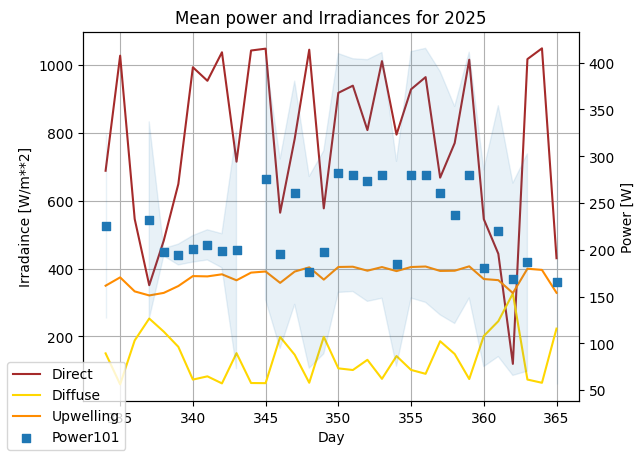

In [212]:
fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(Day_Range2025, Direct_Irradiance_mean_2025, label = 'Direct', color = 'brown')
# ax.fill_between(Day_Range2025, Direct_Irradiance_min_2025, Direct_Irradiance_max_2025, color = 'brown', alpha = .1)

ax.plot(Day_Range2025, Diffuse_Irradiance_mean_2025, label = 'Diffuse', color = 'gold')
ax.plot(Day_Range2025, Upwelling_Irradiance_mean_2025, label = 'Upwelling', color = 'darkorange')

ax2 = ax.twinx()
ax2.scatter(Day_Range2025,Power_101_2025_mean, label = 'Power101', color = 'tab:blue', marker = 's')
# ax2.fill_between(Day_Range2025, Power_101_2025_min, Power_101_2025_max, color = 'tab:blue', alpha = .1)
ax2.fill_between(Day_Range2025, np.array(Power_101_2025_mean)-np.array(Power_101_2025_sd),np.array(Power_101_2025_mean)+np.array(Power_101_2025_sd) , color = 'tab:blue', alpha = .1)

ax.set_ylabel('Irradaince [W/m**2]')
ax2.set_ylabel('Power [W]')
ax.set_xlabel('Day')
ax.set_title(f'Mean power and Irradiances for {2025}')
fig.legend(loc = 'lower left')
ax.grid('on')
plt.show()
# print(f'len(Direct_Irradiance_2025): {len(Direct_Irradiance_2025)}')
# print(f'len(Diffuse_Irradiance_2025): {len(Diffuse_Irradiance_2025)}')
# print(f'len(Upwelling_Irradiance_2025): {len(Upwelling_Irradiance_2025)}')
# print(f'len(Power101_2025): {len(Power101_2025)}')

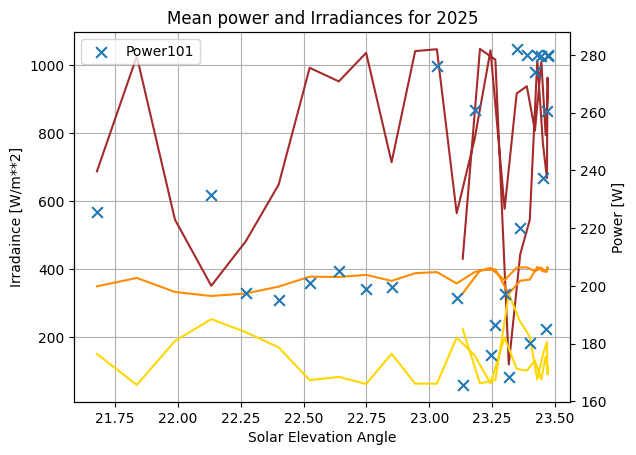

In [213]:
Solar_Elevation_Angle_2025_mean = []
for i in Zenith_Angle_2025_mean:
    Solar_Elevation_Angle_2025_mean.append(90-i)
fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(Solar_Elevation_Angle_2025_mean, Direct_Irradiance_mean_2025, label = 'Direct', color = 'brown')
# ax.fill_between(Day_Range2025, Direct_Irradiance_min_2025, Direct_Irradiance_max_2025, color = 'brown', alpha = .1)

ax.plot(Solar_Elevation_Angle_2025_mean, Diffuse_Irradiance_mean_2025, label = 'Diffuse', color = 'gold')
ax.plot(Solar_Elevation_Angle_2025_mean, Upwelling_Irradiance_mean_2025, label = 'Upwelling', color = 'darkorange')

ax2 = ax.twinx()
ax2.scatter(Solar_Elevation_Angle_2025_mean,Power_101_2025_mean, label = 'Power101', color = 'tab:blue', marker = 'x', s = 60)
# ax2.fill_between(Day_Range2025, Power_101_2025_mean - Power_101_2025_sd, Power_101_2025_mean + Power_101_2025_sd, color = 'tab:blue', alpha = .1)

ax.set_ylabel('Irradaince [W/m**2]')
ax2.set_ylabel('Power [W]')
ax.set_xlabel('Solar Elevation Angle')
ax.set_title(f'Mean power and Irradiances for {2025}')
# ax.set_xscale('log')
plt.legend()
ax.grid('on')
plt.show()

In [214]:
# plt.hist(Power_101_2025_mean, bins = 20)
# plt.show()
# plt.hist(Direct_Irradiance_mean_2025, bins = 50)
# plt.show()

In [215]:
# Now load to 2026 data
Day_Range2026 = np.arange(1, 27, 1)
Direct_Irradiance_mean_2026 = []
Direct_Irradiance_min_2026 = []
Direct_Irradiance_max_2026 = []

Diffuse_Irradiance_mean_2026 = []
Upwelling_Irradiance_mean_2026 = []

Power_101_2026_mean = []
Power_101_2026_min = []
Power_101_2026_max = []
Power_101_2026_sd = []

Zenith_Angle_2026_mean = []
Zenith_Angle_2026_min = []
Zenith_Angle_2026_max = []

for day in Day_Range2026:
    InfoDict = Power_And_Irradiance_MeanMinMax(26, day)
    
    Direct_Irradiance_mean_2026.append(InfoDict['Irradiance_Direct_mean'])
    Direct_Irradiance_min_2026.append(InfoDict['Irradiance_Direct_min'])
    Direct_Irradiance_max_2026.append(InfoDict['Irradiance_Direct_max'])
    
    Diffuse_Irradiance_mean_2026.append(InfoDict['Irradiance_Diffuse_mean'])
    Upwelling_Irradiance_mean_2026.append(InfoDict['Irradiance_Upwelling_mean'])

    Power_101_2026_mean.append(InfoDict['Power_101_mean'])
    Power_101_2026_min.append(InfoDict['Power_101_min'])
    Power_101_2026_max.append(InfoDict['Power_101_max'])
    Power_101_2026_sd.append(InfoDict['Power_101_sd'])

    Zenith_Angle_2026_mean.append(InfoDict['Zenith_Angle_mean'])
    Zenith_Angle_2026_min.append(InfoDict['Zenith_Angle_min'])
    Zenith_Angle_2026_max.append(InfoDict['Zenith_Angle_max'])
print(Power_101_2026_mean)

https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2026/spo26000.dat
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2026/spo26000.dat file not found
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2026/spo26001.dat
File Loaded 1
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2026/spo26001.dat
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2026/spo26002.dat
File Loaded 2
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2026/spo26002.dat
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2026/spo26003.dat


/var/folders/zk/p32hf16n3rnbx31r3xbsvc4m0000gn/T/ipykernel_15037/830476371.py:237: RuntimeWarning: Mean of empty slice
  PowerMeanMinMax = [[np.nanmean(power_101), np.min(power_101), np.max(power_101)],[np.nanmean(power_103), np.min(power_103), np.max(power_103)]]
/var/folders/zk/p32hf16n3rnbx31r3xbsvc4m0000gn/T/ipykernel_15037/830476371.py:239: RuntimeWarning: Mean of empty slice
  Power_101_mean = np.nanmean(power_101)


File Loaded 3
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2026/spo26003.dat
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2026/spo26004.dat
File Loaded 4
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2026/spo26004.dat
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2026/spo26005.dat
File Loaded 5
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2026/spo26005.dat
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2026/spo26006.dat


/var/folders/zk/p32hf16n3rnbx31r3xbsvc4m0000gn/T/ipykernel_15037/830476371.py:237: RuntimeWarning: Mean of empty slice
  PowerMeanMinMax = [[np.nanmean(power_101), np.min(power_101), np.max(power_101)],[np.nanmean(power_103), np.min(power_103), np.max(power_103)]]
/var/folders/zk/p32hf16n3rnbx31r3xbsvc4m0000gn/T/ipykernel_15037/830476371.py:244: RuntimeWarning: Mean of empty slice
  Power_103_mean = np.nanmean(power_103)


File Loaded 6
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2026/spo26006.dat
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2026/spo26007.dat
File Not Loaded
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2026/spo26007.dat
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2026/spo26008.dat
File Loaded 8
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2026/spo26008.dat
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2026/spo26009.dat
File Loaded 9
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2026/spo26009.dat
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2026/spo26010.dat
File Loaded 10
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2026/spo26010.dat
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2026/spo26011.dat
File Not Loaded
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2026/spo26011.dat
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2026/spo26012.dat
File Loaded 12
https://gml.noaa.gov/aftp/data/r

...

/var/folders/zk/p32hf16n3rnbx31r3xbsvc4m0000gn/T/ipykernel_15037/830476371.py:141: RuntimeWarning: Mean of empty slice
  Irradiance_Upwelling_mean = np.nanmean(NZDTup_ir)


File Loaded 24
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2026/spo26024.dat
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2026/spo26025.dat


/var/folders/zk/p32hf16n3rnbx31r3xbsvc4m0000gn/T/ipykernel_15037/830476371.py:141: RuntimeWarning: Mean of empty slice
  Irradiance_Upwelling_mean = np.nanmean(NZDTup_ir)


File Loaded 25
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2026/spo26025.dat
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2026/spo26026.dat
File Not Loaded
[np.float64(177.16811960670708), np.float64(nan), np.float64(135.02603961301938), np.float64(126.74196356551698), np.float64(242.64008279110115), np.float64(244.62433355437201), nan, np.float64(276.736925300533), np.float64(275.4172142885561), np.float64(250.34250246137967), nan, np.float64(215.14361809138032), np.float64(144.16912022662618), np.float64(193.13196449974245), np.float64(267.66172053622444), nan, np.float64(236.71117322160094), np.float64(187.75738134299684), np.float64(140.43014101188226), np.float64(240.17383391849637), np.float64(258.0134308580347), np.float64(227.15521703096408), np.float64(242.92523953728707), np.float64(204.94556853038944), np.float64(139.59313366838745), nan]


/var/folders/zk/p32hf16n3rnbx31r3xbsvc4m0000gn/T/ipykernel_15037/830476371.py:141: RuntimeWarning: Mean of empty slice
  Irradiance_Upwelling_mean = np.nanmean(NZDTup_ir)


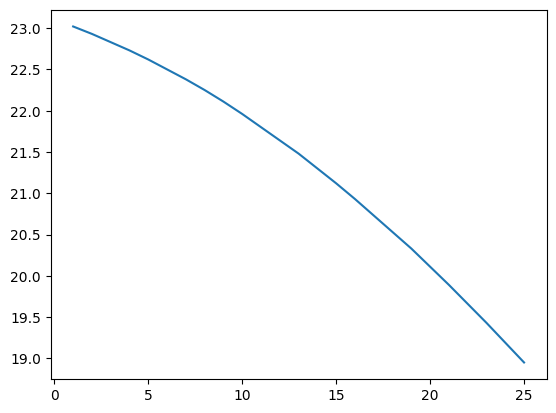

In [216]:


Solar_Elevation_Angle_2026_mean = []
Solar_Elevation_Angle_2026_min = []
Solar_Elevation_Angle_2026_max = []

for i in Zenith_Angle_2026_mean:
    Solar_Elevation_Angle_2026_mean.append(90-i)
for i in Zenith_Angle_2026_min:
    Solar_Elevation_Angle_2026_min.append(90-i)
for i in Zenith_Angle_2026_max:
    Solar_Elevation_Angle_2026_max.append(90-i)


# import datetime

# a = datetime.datetime.today()
# numdays = Day_Range2026[-1]
# dateList = []
# for x in range (Day_Range2026[0], numdays+1):
#     dateList.append(a - datetime.timedelta(days = x))
# # print(dateList)
# print(Day_Range2026)
# print(Solar_Elevation_Angle_2026_mean)
# plt.plot(dateList, Solar_Elevation_Angle_2026_mean, marker = '*', color = 'darkorange')
# plt.title('Solar Elevation angle 2026')
# # plt.fill_between(dateList, Solar_Elevation_Angle_2026_min, Solar_Elevation_Angle_2026_max, alpha = .3, color = 'darkorange')
# plt.grid('on')
# plt.xticks(rotation = 45)
# plt.show()
plt.plot(Solar_Elevation_Angle_2026_min)

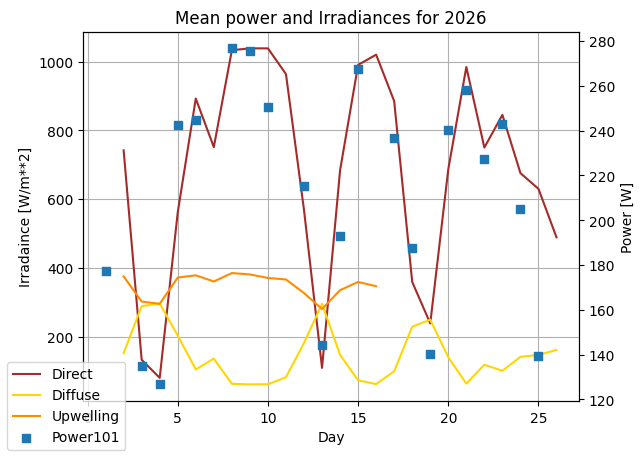

In [271]:



fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(Day_Range2026, Direct_Irradiance_mean_2026, label = 'Direct', color = 'brown')
# ax.fill_between(Day_Range2025, Direct_Irradiance_min_2025, Direct_Irradiance_max_2025, color = 'brown', alpha = .1)

ax.plot(Day_Range2026, Diffuse_Irradiance_mean_2026, label = 'Diffuse', color = 'gold')
ax.plot(Day_Range2026, Upwelling_Irradiance_mean_2026, label = 'Upwelling', color = 'darkorange')

ax2 = ax.twinx()
ax2.scatter(Day_Range2026,Power_101_2026_mean, label = 'Power101', color = 'tab:blue', marker = 's')
# ax2.fill_between(Day_Range2025, Power_101_2025_min, Power_101_2025_max, color = 'tab:blue', alpha = .1)
# ax2.fill_between(Day_Range2026, np.array(Power_101_2026_mean)-np.array(Power_101_2026_sd),np.array(Power_101_2026_mean)+np.array(Power_101_2026_sd) , color = 'tab:blue', alpha = .1)

ax.set_ylabel('Irradaince [W/m**2]')
ax2.set_ylabel('Power [W]')
ax.set_xlabel('Day')
ax.set_title(f'Mean power and Irradiances for {2026}')
fig.legend(loc = 'lower left')
ax.grid('on')
plt.show()

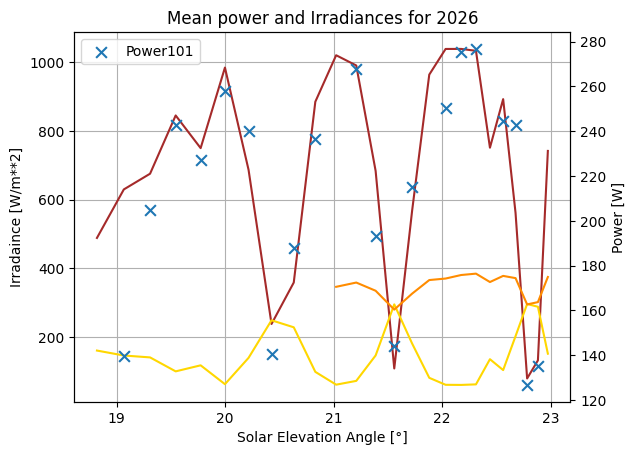

In [218]:
Solar_Elevation_Angle_2026_mean = []
for i in Zenith_Angle_2026_mean:
    Solar_Elevation_Angle_2026_mean.append(90-i)
fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(Solar_Elevation_Angle_2026_mean, Direct_Irradiance_mean_2026, label = 'Direct', color = 'brown')
# ax.fill_between(Day_Range2025, Direct_Irradiance_min_2025, Direct_Irradiance_max_2025, color = 'brown', alpha = .1)

ax.plot(Solar_Elevation_Angle_2026_mean, Diffuse_Irradiance_mean_2026, label = 'Diffuse', color = 'gold')
ax.plot(Solar_Elevation_Angle_2026_mean, Upwelling_Irradiance_mean_2026, label = 'Upwelling', color = 'darkorange')

ax2 = ax.twinx()
ax2.scatter(Solar_Elevation_Angle_2026_mean,Power_101_2026_mean, label = 'Power101', color = 'tab:blue', marker = 'x', s = 60)
# ax2.fill_between(Day_Range2025, Power_101_2025_mean - Power_101_2025_sd, Power_101_2025_mean + Power_101_2025_sd, color = 'tab:blue', alpha = .1)

ax.set_ylabel('Irradaince [W/m**2]')
ax2.set_ylabel('Power [W]')
ax.set_xlabel('Solar Elevation Angle [°]')
ax.set_title(f'Mean power and Irradiances for {2026}')
# ax.set_xscale('log')
plt.legend()
ax.grid('on')
plt.show()

In [219]:
plt.hist(Power101_2026, bins = 20)
plt.show()
plt.hist(Direct_Irradiance_2026, bins = 50)
plt.show()

NameError: name 'Power101_2026' is not defined

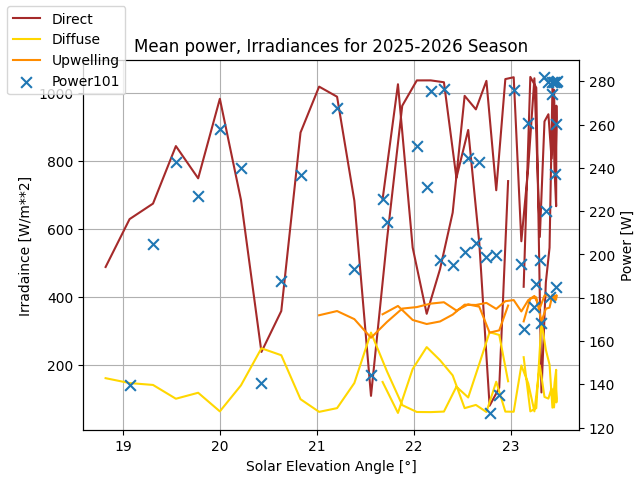

In [220]:
Direct_Irradiance_mean_Combined = np.concat((Direct_Irradiance_mean_2025,Direct_Irradiance_mean_2026))
Diffuse_Irradiance_mean_Combined = np.concat((Diffuse_Irradiance_mean_2025,Diffuse_Irradiance_mean_2026))
Upwelling_Irradiance_mean_Combined = np.concat((Upwelling_Irradiance_mean_2025,Upwelling_Irradiance_mean_2026))
Solar_Elevation_Angle_mean_Combined = np.concat((Solar_Elevation_Angle_2025_mean, Solar_Elevation_Angle_2026_mean))
Power_101_mean_Combined = np.concat((Power_101_2025_mean, Power_101_2026_mean))

fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(Solar_Elevation_Angle_mean_Combined, Direct_Irradiance_mean_Combined, label = 'Direct', color = 'brown')
# ax.fill_between(Day_Range2025, Direct_Irradiance_min_2025, Direct_Irradiance_max_2025, color = 'brown', alpha = .1)

ax.plot(Solar_Elevation_Angle_mean_Combined, Diffuse_Irradiance_mean_Combined, label = 'Diffuse', color = 'gold')
ax.plot(Solar_Elevation_Angle_mean_Combined, Upwelling_Irradiance_mean_Combined, label = 'Upwelling', color = 'darkorange')

ax2 = ax.twinx()
ax2.scatter(Solar_Elevation_Angle_mean_Combined,Power_101_mean_Combined, label = 'Power101', color = 'tab:blue', marker = 'x', s = 60)
# ax2.fill_between(Day_Range2025, Power_101_2025_mean - Power_101_2025_sd, Power_101_2025_mean + Power_101_2025_sd, color = 'tab:blue', alpha = .1)

ax.set_ylabel('Irradaince [W/m**2]')
ax2.set_ylabel('Power [W]')
ax.set_xlabel('Solar Elevation Angle [°]')
ax.set_title(f'Mean power, Irradiances for 2025-2026 Season')
# ax.set_xscale('log')
fig.legend(loc = 'upper left')
ax.grid('on')
plt.show()


In [221]:
# could you show shaded bands instead of the connected lines? 
# you could combine data, in 1deg intervals and find min and max values to define the band
# Direct Band Range
Direct_Band_18_19 = []
Direct_Band_19_20 = []
Direct_Band_20_21 = []
Direct_Band_21_22 = []
Direct_Band_22_23 = []
Direct_Band_23_24 = []
for angle, irr in zip(Solar_Elevation_Angle_mean_Combined, Direct_Irradiance_mean_Combined):
    if 18 <= angle < 19:
        Direct_Band_18_19.append(irr)
    if 19 <= angle < 20:
        Direct_Band_19_20.append(irr)
    if 20 <= angle < 21:
        Direct_Band_20_21.append(irr)
    if 21 <= angle < 22:
        Direct_Band_21_22.append(irr)
    if 22 <= angle < 23:
        Direct_Band_22_23.append(irr)
    if 23 <= angle < 24:
        Direct_Band_23_24.append(irr)

DirectBandMax = np.array([np.max(Direct_Band_18_19), np.max(Direct_Band_19_20), np.max(Direct_Band_20_21), np.max(Direct_Band_21_22), np.max(Direct_Band_22_23), np.max(Direct_Band_23_24)])
DirectBandMin = np.array([np.min(Direct_Band_18_19), np.min(Direct_Band_19_20), np.min(Direct_Band_20_21), np.min(Direct_Band_21_22), np.min(Direct_Band_22_23), np.min(Direct_Band_23_24)])
print(Direct_Irradaince_mean_Combined)
# Diffuse Band Range
Diffuse_Band_18_19 = []
Diffuse_Band_19_20 = []
Diffuse_Band_20_21 = []
Diffuse_Band_21_22 = []
Diffuse_Band_22_23 = []
Diffuse_Band_23_24 = []
for angle, irr in zip(Solar_Elevation_Angle_mean_Combined, Diffuse_Irradiance_mean_Combined):
    if 18 <= angle < 19:
        Diffuse_Band_18_19.append(irr)
    if 19 <= angle < 20:
        Diffuse_Band_19_20.append(irr)
    if 20 <= angle < 21:
        Diffuse_Band_20_21.append(irr)
    if 21 <= angle < 22:
        Diffuse_Band_21_22.append(irr)
    if 22 <= angle < 23:
        Diffuse_Band_22_23.append(irr)
    if 23 <= angle < 24:
        Diffuse_Band_23_24.append(irr)

DiffuseBandMax = np.array([np.max(Diffuse_Band_18_19), np.max(Diffuse_Band_19_20), np.max(Diffuse_Band_20_21), np.max(Diffuse_Band_21_22), np.max(Diffuse_Band_22_23), np.max(Diffuse_Band_23_24)])
DiffuseBandMin = np.array([np.min(Diffuse_Band_18_19), np.min(Diffuse_Band_19_20), np.min(Diffuse_Band_20_21), np.min(Diffuse_Band_21_22), np.min(Diffuse_Band_22_23), np.min(Diffuse_Band_23_24)])

# Upwelling Band Range
Upwelling_Band_18_19 = []
Upwelling_Band_19_20 = []
Upwelling_Band_20_21 = []
Upwelling_Band_21_22 = []
Upwelling_Band_22_23 = []
Upwelling_Band_23_24 = []
for angle, irr in zip(Solar_Elevation_Angle_mean_Combined, Upwelling_Irradiance_mean_Combined):
    if 18 <= angle < 19:
        Upwelling_Band_18_19.append(irr)
    if 19 <= angle < 20:
        Upwelling_Band_19_20.append(irr)
    if 20 <= angle < 21:
        Upwelling_Band_20_21.append(irr)
    if 21 <= angle < 22:
        Upwelling_Band_21_22.append(irr)
    if 22 <= angle < 23:
        Upwelling_Band_22_23.append(irr)
    if 23 <= angle < 24:
        Upwelling_Band_23_24.append(irr)

UpwellingBandMax = np.array([np.max(Upwelling_Band_18_19), np.max(Upwelling_Band_19_20), np.max(Upwelling_Band_20_21), np.max(Upwelling_Band_21_22), np.max(Upwelling_Band_22_23), np.max(Upwelling_Band_23_24)])
UpwellingBandMin = np.array([np.min(Upwelling_Band_18_19), np.min(Upwelling_Band_19_20), np.min(Upwelling_Band_20_21), np.min(Upwelling_Band_21_22), np.min(Upwelling_Band_22_23), np.min(Upwelling_Band_23_24)])

print(DirectBandMax)
print(DirectBandMin)
print(Solar_Elevation_Angle_Combined_mean)
print(len(Solar_Elevation_Angle_Combined_mean))

[ 688.08080169 1027.11421499  545.89283204  350.85977257  482.5460272
  648.87121641  992.97469965  953.09131356 1037.1135785   714.81227209
 1042.29724576 1047.78235709  564.54211633  782.0555791  1044.69992948
  577.29214035  917.55770863  938.72568614  807.87232394 1011.07394366
  794.55395936  928.00882145  963.90901408  667.81389086  769.74196927
 1015.19633803  545.61259622  443.39229692  119.10951389 1016.99950669
 1048.70133992  430.43222222           nan  741.81908506  132.62715278
   79.96173611  561.62215909  892.51483322  751.18853503 1033.00411348
 1038.50834512 1038.4105039   963.73330976  568.34359692  109.03703704
  683.71964912  990.37558386 1020.11252654  884.86066619  359.02361411
  238.39368421  686.82685512  984.2445474   749.94156669  844.97594937
  675.5348951   629.81818182  488.71432604]
[ 488.71432604  984.2445474   884.86066619 1027.11421499 1042.29724576
 1048.70133992]
[488.71432604 629.81818182 238.39368421 109.03703704  79.96173611
 119.10951389]
[21.6777

[488.71432604 629.81818182 238.39368421 109.03703704  79.96173611
 119.10951389]
[18.5 19.5 20.5 21.5 22.5 23.5]


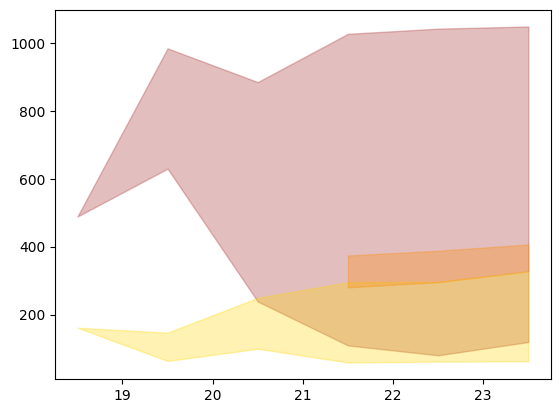

In [222]:
# plt.plot(DirectBandMin)
# plt.plot(DirectBandMax)

# Revmove the first point of datum from each because we don't have much data before lower than 19 degrees
DirectBandMin = DirectBandMin
DiffuseBandMin = DiffuseBandMin
UpwellingBandMin = UpwellingBandMin

DirectBandMax = DirectBandMax
DiffuseBandMax = DiffuseBandMax
UpwellingBandMax = UpwellingBandMax

print(DirectBandMin)
SolarElevationAngle_test = np.arange(18.5,len(DirectBandMin)+18.5,1)
print(SolarElevationAngle_test)

plt.fill_between(SolarElevationAngle_test,DirectBandMin, DirectBandMax, color = 'brown', alpha = .3)
plt.fill_between(SolarElevationAngle_test,DiffuseBandMin, DiffuseBandMax, color = 'gold', alpha = .3)
plt.fill_between(SolarElevationAngle_test,UpwellingBandMin, UpwellingBandMax, color = 'darkorange', alpha = .3)



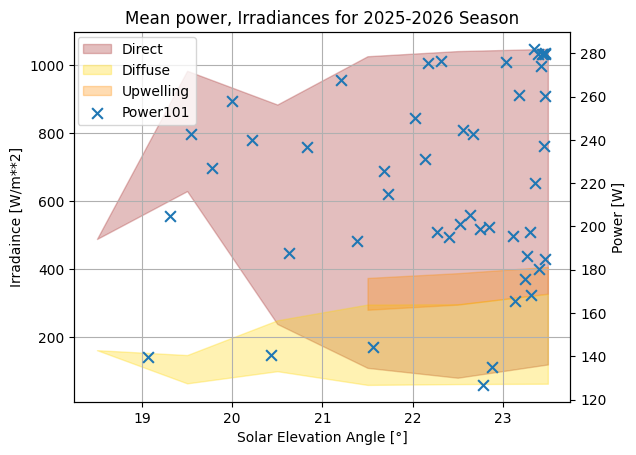

In [223]:
Direct_Irradiance_mean_Combined = np.concat((Direct_Irradiance_mean_2025,Direct_Irradiance_mean_2026))
Diffuse_Irradiance_mean_Combined = np.concat((Diffuse_Irradiance_mean_2025,Diffuse_Irradiance_mean_2026))
Upwelling_Irradiance_mean_Combined = np.concat((Upwelling_Irradiance_mean_2025,Upwelling_Irradiance_mean_2026))
Solar_Elevation_Angle_mean_Combined = np.concat((Solar_Elevation_Angle_2025_mean, Solar_Elevation_Angle_2026_mean))
Power_101_mean_Combined = np.concat((Power_101_2025_mean, Power_101_2026_mean))

fig = plt.figure()
ax = fig.add_subplot(111)
# ax.plot(Solar_Elevation_Angle_mean_Combined, Direct_Irradiance_mean_Combined, label = 'Direct', color = 'brown')
# ax.fill_between(Day_Range2025, Direct_Irradiance_min_2025, Direct_Irradiance_max_2025, color = 'brown', alpha = .1)

# ax.plot(Solar_Elevation_Angle_mean_Combined, Diffuse_Irradiance_mean_Combined, label = 'Diffuse', color = 'gold')
# ax.plot(Solar_Elevation_Angle_mean_Combined, Upwelling_Irradiance_mean_Combined, label = 'Upwelling', color = 'darkorange')

ax2 = ax.twinx()
ax2.scatter(Solar_Elevation_Angle_mean_Combined,Power_101_mean_Combined, label = 'Power101', color = 'tab:blue', marker = 'x', s = 60)
# ax2.fill_between(Day_Range2025, Power_101_2025_mean - Power_101_2025_sd, Power_101_2025_mean + Power_101_2025_sd, color = 'tab:blue', alpha = .1)

ax.fill_between(SolarElevationAngle_test,DirectBandMin, DirectBandMax, color = 'brown', alpha = .3, label = 'Direct')
ax.fill_between(SolarElevationAngle_test,DiffuseBandMin, DiffuseBandMax, color = 'gold', alpha = .3, label = 'Diffuse')
ax.fill_between(SolarElevationAngle_test,UpwellingBandMin, UpwellingBandMax, color = 'darkorange', alpha = .3, label = 'Upwelling')

ax.set_ylabel('Irradaince [W/m**2]')
ax2.set_ylabel('Power [W]')
ax.set_xlabel('Solar Elevation Angle [°]')
ax.set_title(f'Mean power, Irradiances for 2025-2026 Season')
# ax.set_xscale('log')
fig.legend(loc = 'upper left', bbox_to_anchor=(.13, .87),
    borderaxespad=0)
ax.grid('on')
plt.show()

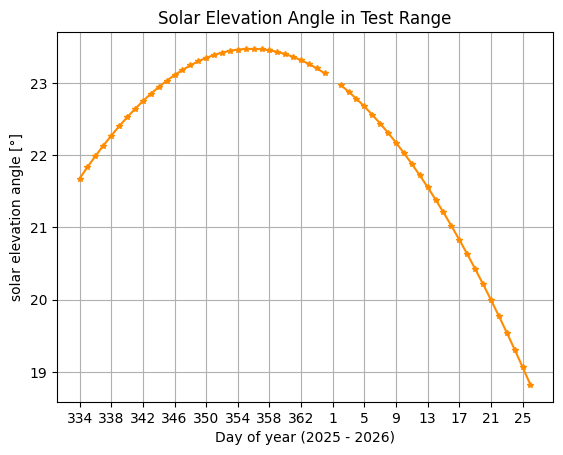

In [273]:
Day_Range2025_string = []
Day_Range2026_string = []
for day in Day_Range2025:
    Day_Range2025_string.append(str(day))
for day in Day_Range2026:
    Day_Range2026_string.append(str(day))
plt.plot(np.concat((Day_Range2025_string,Day_Range2026_string)),Solar_Elevation_Angle_Combined_mean, color = 'darkorange', marker = '*', markersize = '4')
plt.xticks(np.concat((Day_Range2025_string,Day_Range2026_string))[::4])
plt.title(f'Solar Elevation Angle in Test Range')
plt.xlabel('Day of year (2025 - 2026)')
plt.ylabel('solar elevation angle [°]')
plt.grid('on')
plt.show()

In [225]:
# Now do panel 103 data

Power_103_2025_mean = []
for day in Day_Range2025:
    InfoDict = Power_And_Irradiance_MeanMinMax(25, day)
    Power_103_2025_mean.append(InfoDict['Power_103_mean'])
Power_103_2026_mean = []
for day in Day_Range2026:
    InfoDict = Power_And_Irradiance_MeanMinMax(26,day)
    Power_103_2026_mean.append(InfoDict['Power_103_mean'])


https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2025/spo25333.dat
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2025/spo25334.dat
File Loaded 334
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2025/spo25334.dat
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2025/spo25335.dat
File Not Loaded
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2025/spo25335.dat
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2025/spo25336.dat
File Not Loaded
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2025/spo25336.dat
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2025/spo25337.dat
File Loaded 337
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2025/spo25337.dat
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2025/spo25338.dat
File Loaded 338
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2025/spo25338.dat
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2025/spo25339.dat
File Loaded 339
https://gml.noaa.gov/aftp/data/radiation

/var/folders/zk/p32hf16n3rnbx31r3xbsvc4m0000gn/T/ipykernel_15037/830476371.py:237: RuntimeWarning: Mean of empty slice
  PowerMeanMinMax = [[np.nanmean(power_101), np.min(power_101), np.max(power_101)],[np.nanmean(power_103), np.min(power_103), np.max(power_103)]]
/var/folders/zk/p32hf16n3rnbx31r3xbsvc4m0000gn/T/ipykernel_15037/830476371.py:239: RuntimeWarning: Mean of empty slice
  Power_101_mean = np.nanmean(power_101)


File Loaded 3
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2026/spo26003.dat
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2026/spo26004.dat
File Loaded 4
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2026/spo26004.dat
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2026/spo26005.dat
File Loaded 5
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2026/spo26005.dat
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2026/spo26006.dat


/var/folders/zk/p32hf16n3rnbx31r3xbsvc4m0000gn/T/ipykernel_15037/830476371.py:237: RuntimeWarning: Mean of empty slice
  PowerMeanMinMax = [[np.nanmean(power_101), np.min(power_101), np.max(power_101)],[np.nanmean(power_103), np.min(power_103), np.max(power_103)]]
/var/folders/zk/p32hf16n3rnbx31r3xbsvc4m0000gn/T/ipykernel_15037/830476371.py:244: RuntimeWarning: Mean of empty slice
  Power_103_mean = np.nanmean(power_103)


File Loaded 6
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2026/spo26006.dat
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2026/spo26007.dat
File Not Loaded
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2026/spo26007.dat
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2026/spo26008.dat
File Loaded 8
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2026/spo26008.dat
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2026/spo26009.dat
File Loaded 9
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2026/spo26009.dat
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2026/spo26010.dat
File Loaded 10
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2026/spo26010.dat
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2026/spo26011.dat
File Not Loaded
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2026/spo26011.dat
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2026/spo26012.dat
File Loaded 12
https://gml.noaa.gov/aftp/data/r

...

/var/folders/zk/p32hf16n3rnbx31r3xbsvc4m0000gn/T/ipykernel_15037/830476371.py:141: RuntimeWarning: Mean of empty slice
  Irradiance_Upwelling_mean = np.nanmean(NZDTup_ir)


File Loaded 24
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2026/spo26024.dat
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2026/spo26025.dat


/var/folders/zk/p32hf16n3rnbx31r3xbsvc4m0000gn/T/ipykernel_15037/830476371.py:141: RuntimeWarning: Mean of empty slice
  Irradiance_Upwelling_mean = np.nanmean(NZDTup_ir)


File Loaded 25
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2026/spo26025.dat
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2026/spo26026.dat
File Not Loaded


/var/folders/zk/p32hf16n3rnbx31r3xbsvc4m0000gn/T/ipykernel_15037/830476371.py:141: RuntimeWarning: Mean of empty slice
  Irradiance_Upwelling_mean = np.nanmean(NZDTup_ir)


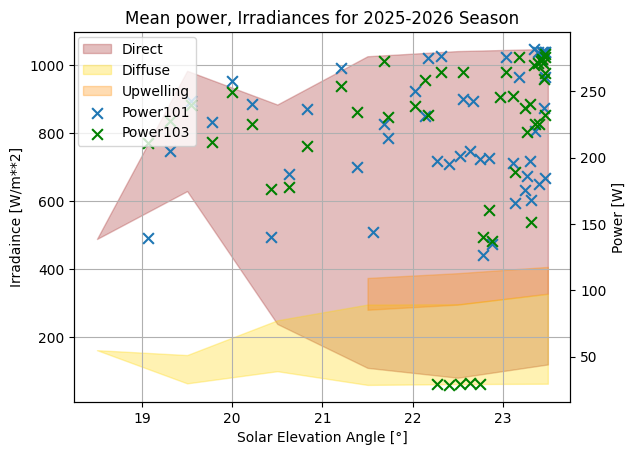

In [226]:
Power_103_mean_Combined = np.concat((Power_103_2025_mean, Power_103_2026_mean))

fig = plt.figure()
ax = fig.add_subplot(111)
# ax.plot(Solar_Elevation_Angle_mean_Combined, Direct_Irradiance_mean_Combined, label = 'Direct', color = 'brown')
# ax.fill_between(Day_Range2025, Direct_Irradiance_min_2025, Direct_Irradiance_max_2025, color = 'brown', alpha = .1)

# ax.plot(Solar_Elevation_Angle_mean_Combined, Diffuse_Irradiance_mean_Combined, label = 'Diffuse', color = 'gold')
# ax.plot(Solar_Elevation_Angle_mean_Combined, Upwelling_Irradiance_mean_Combined, label = 'Upwelling', color = 'darkorange')

ax2 = ax.twinx()
ax2.scatter(Solar_Elevation_Angle_mean_Combined,Power_101_mean_Combined, label = 'Power101', color = 'tab:blue', marker = 'x', s = 60)
ax2.scatter(Solar_Elevation_Angle_mean_Combined,Power_103_mean_Combined, label = 'Power103', color = 'green', marker = 'x', s = 60)

# ax2.fill_between(Day_Range2025, Power_101_2025_mean - Power_101_2025_sd, Power_101_2025_mean + Power_101_2025_sd, color = 'tab:blue', alpha = .1)

ax.fill_between(SolarElevationAngle_test,DirectBandMin, DirectBandMax, color = 'brown', alpha = .3, label = 'Direct')
ax.fill_between(SolarElevationAngle_test,DiffuseBandMin, DiffuseBandMax, color = 'gold', alpha = .3, label = 'Diffuse')
ax.fill_between(SolarElevationAngle_test,UpwellingBandMin, UpwellingBandMax, color = 'darkorange', alpha = .3, label = 'Upwelling')



ax.set_ylabel('Irradaince [W/m**2]')
ax2.set_ylabel('Power [W]')
ax.set_xlabel('Solar Elevation Angle [°]')
ax.set_title(f'Mean power, Irradiances for 2025-2026 Season')
# ax.set_xscale('log')
fig.legend(loc = 'upper left', bbox_to_anchor=(.13, .87),
    borderaxespad=0)
ax.grid('on')
plt.show()

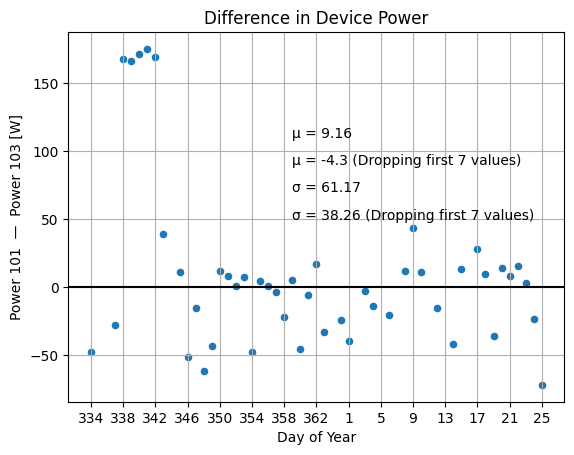

In [270]:
plt.axhline(y=00, color='black', linestyle='-')
plt.grid('on')
plt.scatter(np.concat((Day_Range2025_string,Day_Range2026_string)),Power_101_mean_Combined - Power_103_mean_Combined, s = 20)
plt.xticks(np.concat((Day_Range2025_string,Day_Range2026_string))[::4])
plt.title('Difference in Device Power')
plt.ylabel('Power 101  —  Power 103 [W]')
plt.xlabel('Day of Year')
plt.text(25,70,f'σ = {round(np.nanstd((Power_101_mean_Combined - Power_103_mean_Combined)), 2)}')
plt.text(25,50,f'σ = {round(np.nanstd((Power_101_mean_Combined - Power_103_mean_Combined)[8:]), 2)} (Dropping first 7 values)')

plt.text(25,70+40,f'μ = {round(np.nanmean((Power_101_mean_Combined - Power_103_mean_Combined)), 2)}')
plt.text(25,50+40,f'μ = {round(np.nanmean((Power_101_mean_Combined - Power_103_mean_Combined)[8:]), 2)} (Dropping first 7 values)')


plt.show()

